# Image Classification on CIFAR-10 using ANN and CNN

In this notebook, I compare the performance of a traditional Artificial Neural Network(ANN) and a Convolutional Neural Network(CNN) on the CIFAR-10 dataset. The goal is to understand how both models learn from image data and to observe the difference in their accuracy and generalization.

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models,callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Loading the Dataset

The CIFAR-10 dataset is already available in TensorFlow. It contains 60,000 color images of size 32 × 32 belonging to 10 different categories such as airplanes, cars, birds, cats, and ships.

The dataset is divided into training and testing sets so that the models can be trained and evaluated separately.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2868s 17us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## Exploring the Dataset

Before training any model, it is useful to look at a few sample images. This helps verify that the dataset has loaded correctly and gives a better idea of the type of images the model will be learning from.

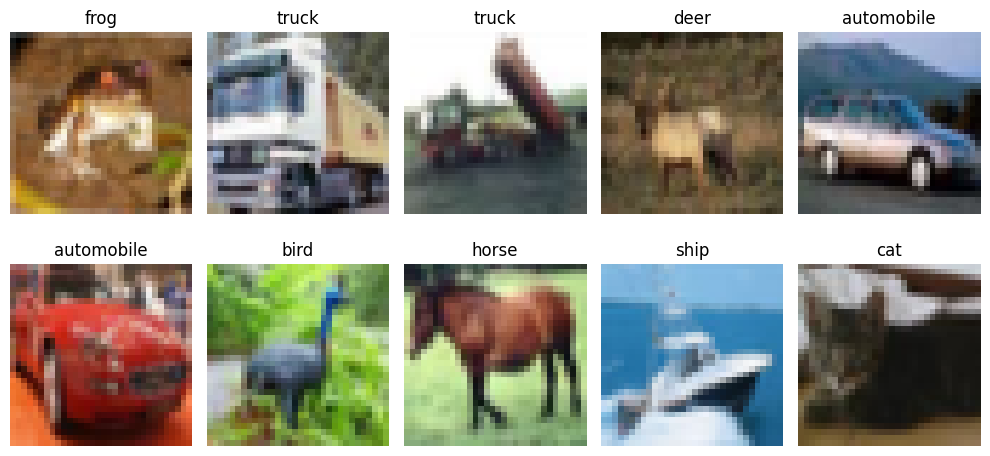

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Data Preprocessing

Neural networks perform better when the input values are on a similar scale. Since pixel values range from 0 to 255, they are normalized by dividing each value by 255.

For the ANN model, the images are also flattened into one-dimensional vectors because dense layers cannot directly process two-dimensional image data.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

## Building the Artificial Neural Network

The first model is a fully connected neural network. Since ANN layers cannot directly understand image structure, each image is converted into a single vector before being passed through the network.

This model serves as a baseline for comparison with the CNN.

In [5]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512,  activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256,  activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128,  activation='relu'),
    layers.Dense(10,   activation='softmax')
], name="ANN_Deep")
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
ann_model.summary()

Model: "ANN_Deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

## Training the ANN

The ANN is trained using the training dataset while a portion of the data is reserved for validation. The validation accuracy helps monitor how well the model performs on data that it has not seen during training.

In [15]:
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nANN Test Accuracy: {ann_test_acc:.4f}")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.3783 - loss: 1.7111 - val_accuracy: 0.4208 - val_loss: 1.6663
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.3858 - loss: 1.6925 - val_accuracy: 0.4284 - val_loss: 1.6355
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.3880 - loss: 1.6897 - val_accuracy: 0.4254 - val_loss: 1.6253
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.3896 - loss: 1.6806 - val_accuracy: 0.4216 - val_loss: 1.6461
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.3967 - loss: 1.6686 - val_accuracy: 0.4180 - val_loss: 1.6685
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.3971 - loss: 1.6655 - val_accuracy: 0.4256 - val_loss: 1.6298
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.4014 - loss: 1.6630 - val_accuracy: 0.4456 - val_loss: 1.6131
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.4028 - loss: 1.6508 - 

## Building the Convolutional Neural Network

Unlike an ANN, a CNN is designed specifically for image data. Convolutional layers automatically learn useful features such as edges, shapes, and textures, while pooling layers reduce the size of feature maps and help the model focus on important information.

Because of this, CNNs usually perform much better on image classification tasks.

In [7]:

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10,  activation='softmax')
], name="CNN")
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

## Preventing Overfitting

To improve the model's ability to generalize, two techniques are used.

- Early Stopping stops training when the validation performance no longer improves.
- Data Augmentation creates slightly modified versions of training images, allowing the model to learn from a wider variety of examples.

In [10]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nCNN Test Accuracy: {cnn_test_acc:.4f}")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 121ms/step - accuracy: 0.4512 - loss: 1.5425 - val_accuracy: 0.5290 - val_loss: 1.3273
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.6063 - loss: 1.1223 - val_accuracy: 0.5220 - val_loss: 1.3717
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 119ms/step - accuracy: 0.6697 - loss: 0.9359 - val_accuracy: 0.6974 - val_loss: 0.8676
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.7200 - loss: 0.8013 - val_accuracy: 0.6282 - val_loss: 1.0699
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.7594 - loss: 0.6883 - val_accuracy: 0.6832 - val_loss: 0.9546
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.7894 - loss: 0.6023 - val_accuracy: 0.7114 - val_loss: 0.8591
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.8126 - loss: 0.5261 - val_accuracy: 0.7500 - val_loss: 0.7709
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.8366 - loss: 

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name="augmentation")
aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10,  activation='softmax')
], name="Augmented_CNN")
aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
aug_early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
)
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[aug_early_stop],
    verbose=1
)
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nAugmented CNN Test Accuracy: {aug_test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 126ms/step - accuracy: 0.3658 - loss: 1.7513 - val_accuracy: 0.5166 - val_loss: 1.3196
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.4740 - loss: 1.4647 - val_accuracy: 0.5464 - val_loss: 1.2570
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.5272 - loss: 1.3334 - val_accuracy: 0.5972 - val_loss: 1.1906
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 125ms/step - accuracy: 0.5615 - loss: 1.2434 - val_accuracy: 0.6576 - val_loss: 0.9816
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.5911 - loss: 1.1668 - val_accuracy: 0.6106 - val_loss: 1.1965
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 122ms/step - accuracy: 0.6154 - loss: 1.1097 - val_accuracy: 0.6610 - val_loss: 0.9648
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.6301 - loss: 1.0662 - val_accuracy: 0.6782 - val_loss: 0.9404
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.6419 - loss:

## Comparing Training Performance

The validation accuracy of both models is plotted over multiple epochs. This makes it easier to see how quickly each model learns and which one achieves better performance.

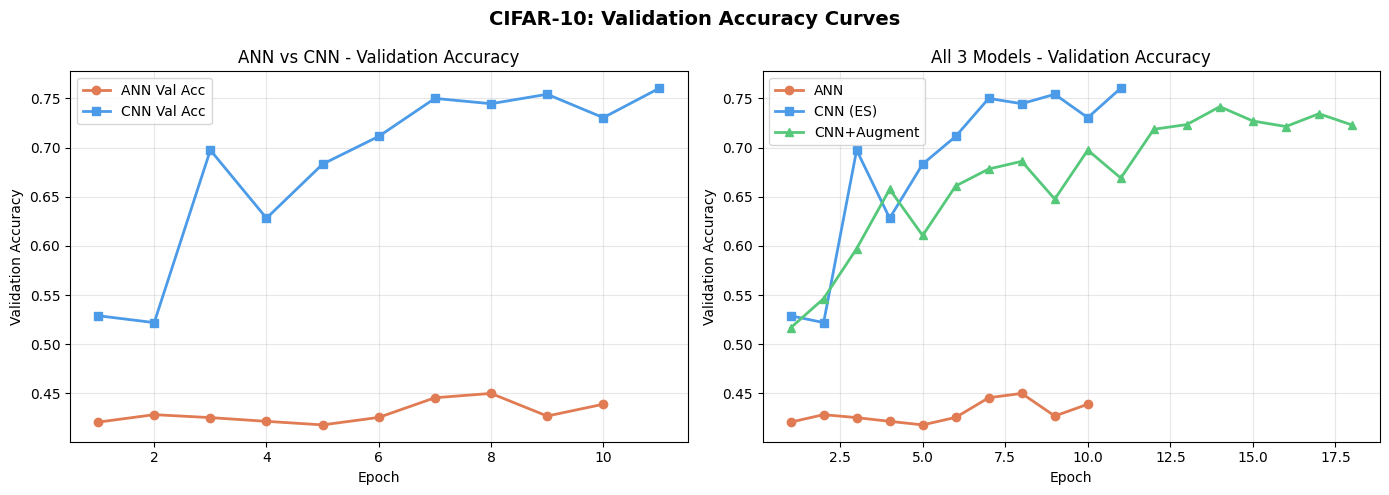

In [16]:

ann_val = ann_history.history['val_accuracy']
cnn_val = cnn_history.history['val_accuracy']
aug_val = aug_history.history['val_accuracy']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(ann_val)+1), ann_val, 'o-', color='#E07B54', label='ANN Val Acc', lw=2)
axes[0].plot(range(1, len(cnn_val)+1), cnn_val, 's-', color='#4C9BE8', label='CNN Val Acc', lw=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation Accuracy")
axes[0].set_title("ANN vs CNN - Validation Accuracy")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(ann_val)+1), ann_val, 'o-', color='#E07B54', label='ANN',           lw=2)
axes[1].plot(range(1, len(cnn_val)+1), cnn_val, 's-', color='#4C9BE8', label='CNN (ES)',       lw=2)
axes[1].plot(range(1, len(aug_val)+1), aug_val, '^-', color='#55C87A', label='CNN+Augment',    lw=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("All 3 Models - Validation Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
fig.suptitle("CIFAR-10: Validation Accuracy Curves", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Model Comparison

The final results of both models are summarized in a table. Comparing their accuracy provides a clear picture of how much improvement is achieved by using a CNN instead of a simple ANN for image classification.

In [14]:
comparison = pd.DataFrame({
    "Model":         ["ANN (Deep 4-layer)",
                      "CNN (32→64→128, EarlyStopping)",
                      "CNN + Augmentation"],
    "Beginner Task": ["Dense Layers",
                      "Filters, 20ep, ES",
                      "Data Augmentation"],
    "Epochs Run":    [len(ann_val), len(cnn_val), len(aug_val)],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc],
    "Test Loss":     [ann_test_loss, cnn_test_loss, aug_test_loss],
})
display(comparison)

,Model,Beginner Task,Epochs Run,Test Accuracy,Test Loss
0,ANN (Deep 4-layer),Dense Layers,10,0.4239,1.638932
1,"CNN (32→64→128, EarlyStopping)","Filters, 20ep, ES",11,0.7327,0.825782
2,CNN + Augmentation,Data Augmentation,18,0.7285,0.786131


# Conclusion

Both models were trained on the same dataset, but their performance was noticeably different.

The ANN was able to learn basic patterns from the images, but its accuracy was limited because it treated every pixel independently. The CNN performed significantly better because it could capture spatial features such as edges, textures, and shapes through convolutional layers.

This experiment highlights why CNNs are generally preferred over traditional neural networks for image classification tasks.